# Titanic Survival Modeling

End‑to‑end modeling to predict **Survived** using a clean Titanic dataset. We compare baselines with stratified cross‑validation, train a stronger Gradient Boosting model with class weighting, select the number of boosting rounds via staged evaluation, pick an operating threshold, and generate Kaggle‑style submissions.

## What I’ll Do
1. Load processed data and make a stratified train/validation split.
2. Build a reusable preprocessing pipeline (`src.features.build_preprocess_pipeline`).
3. Compare baseline models via 5‑fold Stratified CV (accuracy/precision/recall/F1).
4. Train the CV winner and evaluate on the validation set.
5. Fit a class‑weighted Gradient Boosting model (via `sample_weight`).
6. Use staged evaluation to pick `n_estimators` and select a probability threshold.
7. Inspect feature importances and persist the best pipeline.
8. Train on full data and create submissions (default and custom threshold).

## Notes
- All code comments are in English.
- Local modules: `src.features` (preprocessing) and `src.models` (model zoo).
- The preprocessor is created from the train schema but is only fitted inside each pipeline/CV fold to avoid leakage.
- If your scikit‑learn < 1.2, change `OneHotEncoder(sparse_output=False)` to `sparse=False`.


In [1]:
# --- Environment & Imports ---
from pathlib import Path
import sys

# Add project root to sys.path so we can `from src...` import
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root set to:", ROOT)

# Core libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import GradientBoostingClassifier

# Project modules
from src.features import build_preprocess_pipeline
from src.models import get_models


Project root set to: C:\Users\hasti_aksoy\OneDrive\Desktop\Titanic


## Load Data + Stratified Split

Read `../data/processed/train_clean.csv`, separate target `Survived`, drop leakage/id (`PassengerId`), and perform a stratified split to preserve class balance across train/validation.


In [2]:
# Load processed dataset
train_clean = pd.read_csv(Path("../data/processed/train_clean.csv"))

# Target and features
y = train_clean["Survived"]
X = train_clean.drop(columns=["Survived", "PassengerId"])  # drop IDs/leakage

# Stratified split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_valid.shape, y_train.mean(), y_valid.mean()


((712, 14),
 (179, 14),
 np.float64(0.38342696629213485),
 np.float64(0.3854748603351955))

## Preprocessing + Model Zoo

`build_preprocess_pipeline(df)` returns a `ColumnTransformer` with:
- Numeric: median impute + standardize
- Binary: passthrough
- Categorical: most‑frequent impute + one‑hot (ignore unknowns)

We create it from the train schema and keep it unfitted so each CV fold fits it only on its training portion. `get_models()` provides a few quick baselines (logistic regression, random forest, gradient boosting, SVM, KNN).


In [3]:
# IMPORTANT: pass train schema; the transformer must be FIT inside each Pipeline/CV fold
pre = build_preprocess_pipeline(X_train.assign(Survived=y_train))

# Candidate models to compare
models = get_models()
print("Candidates:", list(models.keys()))


Candidates: ['logreg', 'rf', 'gb', 'svm', 'knn']


## Baseline Model Comparison (5‑fold Stratified CV)

Each model is wrapped with the preprocessor in a `Pipeline` and evaluated via 5‑fold Stratified CV on the full training data. We collect accuracy, precision, recall, and F1. The top F1 model is selected for a dedicated train/validation fit.

Tip: SVM with `probability=True` can be slower. Remove it from the zoo if runtime is tight.


In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, model in models.items():
    pipe = Pipeline([("pre", pre), ("clf", model)])
    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"],
        n_jobs=-1,
        return_train_score=False
    )
    cv_scores[name] = {k: float(v.mean()) for k, v in scores.items() if "time" not in k}

cv_df = pd.DataFrame(cv_scores).T.sort_values("test_f1", ascending=False)
print(cv_df)
best_name = cv_df['test_f1'].idxmax()
print("Best by CV:", best_name)


        test_accuracy  test_precision  test_recall   test_f1
gb           0.840600        0.821275     0.748423  0.782284
svm          0.835007        0.806472     0.751321  0.777275
logreg       0.828259        0.788593     0.754177  0.770854
rf           0.813653        0.768406     0.739727  0.753294
knn          0.814801        0.798143     0.692882  0.741614
Best by CV: gb


## Train CV Winner → Evaluate on Validation

Refit the winning model on `X_train/y_train` (with preprocessing) and evaluate on `X_valid/y_valid`: classification report, confusion matrix, and ROC curve (when supported).


Model: gb
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



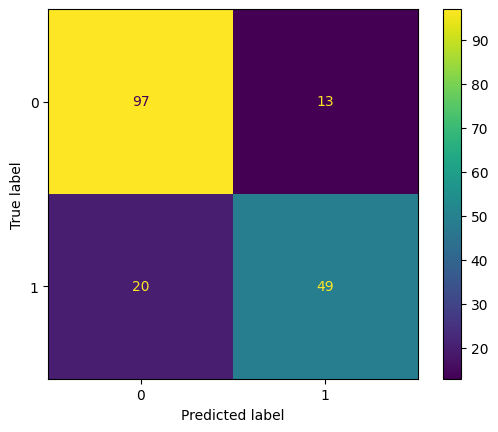

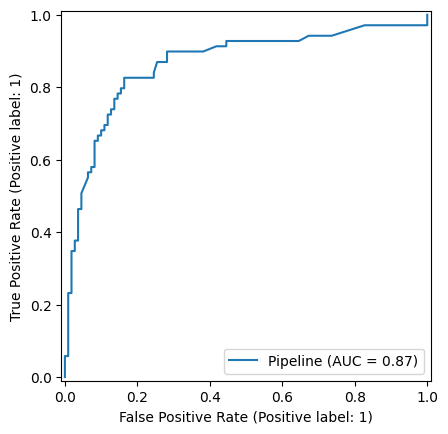

In [5]:
winner = models[best_name]
pipe_win = Pipeline([("pre", build_preprocess_pipeline(X_train.assign(Survived=y_train))), ("clf", winner)])
pipe_win.fit(X_train, y_train)

# Predictions
y_pred = pipe_win.predict(X_valid)
print(f"Model: {best_name}")
print(classification_report(y_valid, y_pred))
ConfusionMatrixDisplay.from_estimator(pipe_win, X_valid, y_valid); plt.show()

# ROC curve if supported
try:
    RocCurveDisplay.from_estimator(pipe_win, X_valid, y_valid); plt.show()
except Exception:
    pass


## Class‑Weighted Gradient Boosting

`GradientBoostingClassifier` has no `class_weight`, but it accepts `sample_weight` in `fit`. We compute balanced class weights with `compute_class_weight` and map them to training rows. This often improves recall on the minority class.


Class weights: {np.int64(0): np.float64(0.8109339407744874), np.int64(1): np.float64(1.304029304029304)}
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       110
           1       0.72      0.77      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.80      0.79      0.79       179



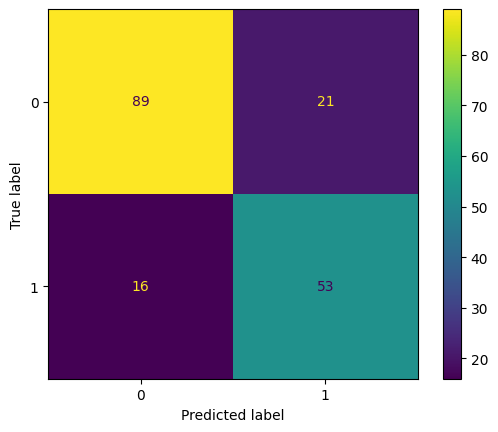

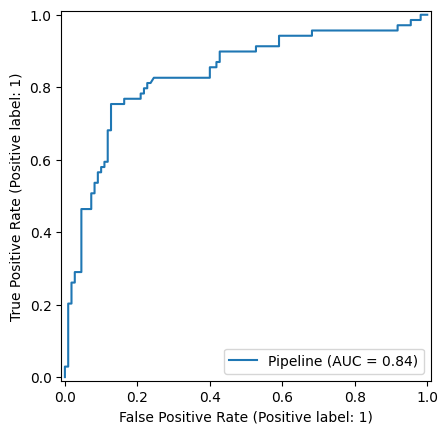

In [6]:
# Compute class weights on training target
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
w_map = dict(zip(classes, weights))
sample_w_train = y_train.map(w_map).values
print("Class weights:", w_map)

gb_weighted = GradientBoostingClassifier(
    loss="log_loss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=2,
    min_samples_split=5,
    min_samples_leaf=1,
    subsample=0.8,
    random_state=42
)

pipe_gb_w = Pipeline([
    ("pre", build_preprocess_pipeline(X_train.assign(Survived=y_train))),
    ("clf", gb_weighted)
])

pipe_gb_w.fit(X_train, y_train, clf__sample_weight=sample_w_train)

# Validate
y_pred_w = pipe_gb_w.predict(X_valid)
print(classification_report(y_valid, y_pred_w))
ConfusionMatrixDisplay.from_estimator(pipe_gb_w, X_valid, y_valid); plt.show()
try:
    RocCurveDisplay.from_estimator(pipe_gb_w, X_valid, y_valid); plt.show()
except Exception:
    pass


## Fast GB Tuning (Staged Evaluation) + Threshold

Train a large GB once, then use `staged_predict_proba` on validation to compute F1 per boosting stage and pick the best `n_estimators`. Refit a compact model with that `n`.

Next, sweep probability thresholds on validation to pick an operating point (`best_thr`) that maximizes F1. This can beat the default 0.5 threshold when classes are imbalanced.


Best n_estimators from staged evaluation: 1141 | best valid F1 @0.5: 0.766
              precision    recall  f1-score   support

           0     0.8598    0.8364    0.8479       110
           1     0.7500    0.7826    0.7660        69

    accuracy                         0.8156       179
   macro avg     0.8049    0.8095    0.8069       179
weighted avg     0.8175    0.8156    0.8163       179



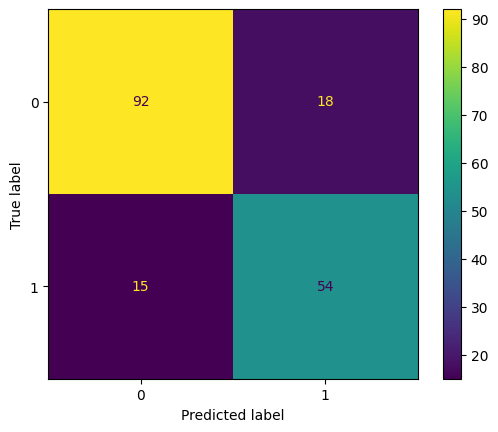

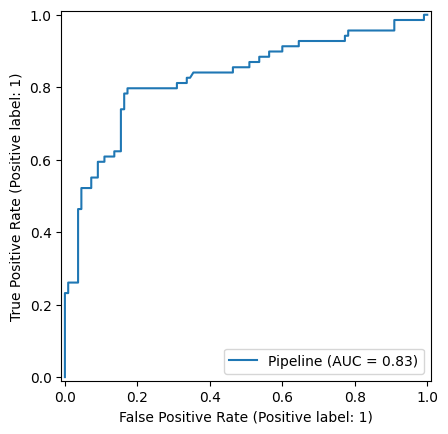

Best threshold on validation: 0.5 | F1: 0.766


In [7]:
# 1) Train one big model once
gb_probe = GradientBoostingClassifier(
    loss="log_loss",
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)

pipe_probe = Pipeline([
    ("pre", build_preprocess_pipeline(X_train.assign(Survived=y_train))),
    ("clf", gb_probe)
])

pipe_probe.fit(X_train, y_train, clf__sample_weight=sample_w_train)

# 2) Pick best n_estimators using validation (threshold=0.5 here)
probas_iter = []
Xv_trans = pipe_probe.named_steps["pre"].transform(X_valid)
for proba in pipe_probe.named_steps["clf"].staged_predict_proba(Xv_trans):
    probas_iter.append(proba[:, 1])

f1s = [f1_score(y_valid, (p >= 0.5).astype(int)) for p in probas_iter]
best_n = int(np.argmax(f1s)) + 1
print("Best n_estimators from staged evaluation:", best_n, "| best valid F1 @0.5:", round(max(f1s), 4))

# 3) Refit a compact model with best_n on train
gb_bestn = GradientBoostingClassifier(
    loss="log_loss",
    n_estimators=best_n,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)

best_gb = Pipeline([
    ("pre", build_preprocess_pipeline(X_train.assign(Survived=y_train))),
    ("clf", gb_bestn)
])
best_gb.fit(X_train, y_train, clf__sample_weight=sample_w_train)

# 4) Evaluate on validation quickly
y_pred = best_gb.predict(X_valid)
print(classification_report(y_valid, y_pred, digits=4))
ConfusionMatrixDisplay.from_estimator(best_gb, X_valid, y_valid); plt.show()
try:
    RocCurveDisplay.from_estimator(best_gb, X_valid, y_valid); plt.show()
except Exception:
    pass

# 5) Threshold sweep on validation to set best_thr
proba_valid = best_gb.predict_proba(X_valid)[:, 1]
grid_thr = np.linspace(0.05, 0.95, 181)
f1s_thr = [f1_score(y_valid, (proba_valid >= t).astype(int)) for t in grid_thr]
best_thr = float(grid_thr[int(np.argmax(f1s_thr))])
print("Best threshold on validation:", round(best_thr, 3), "| F1:", round(max(f1s_thr), 4))


## Evaluate Best GB on Validation

Quick validation check: classification report, confusion matrix, and ROC (if supported).


              precision    recall  f1-score   support

           0     0.8598    0.8364    0.8479       110
           1     0.7500    0.7826    0.7660        69

    accuracy                         0.8156       179
   macro avg     0.8049    0.8095    0.8069       179
weighted avg     0.8175    0.8156    0.8163       179



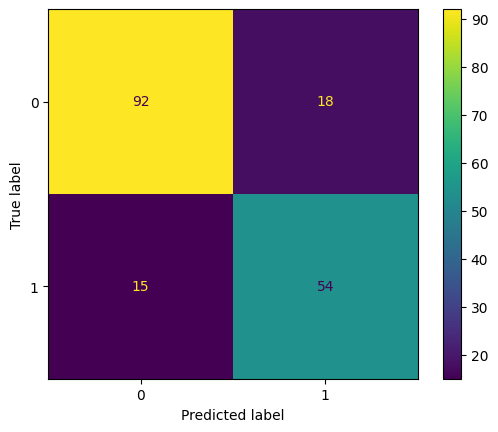

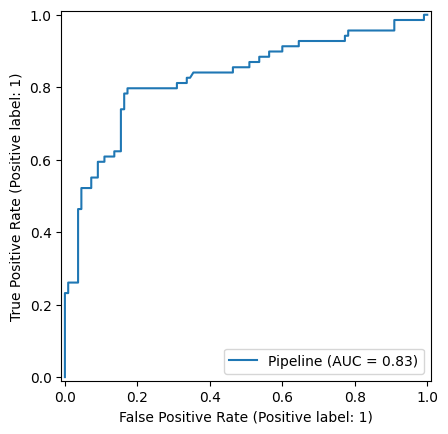

In [8]:
# Ensure we have a fitted best estimator
try:
    _ = best_gb
except NameError as _:
    raise RuntimeError("No 'best_gb' found. Please fit a model first.")

# Predict on validation
y_pred_best = best_gb.predict(X_valid)
print(classification_report(y_valid, y_pred_best, digits=4))
ConfusionMatrixDisplay.from_estimator(best_gb, X_valid, y_valid); plt.show()
try:
    RocCurveDisplay.from_estimator(best_gb, X_valid, y_valid); plt.show()
except Exception:
    pass


## Feature Importances (GB)

Extract transformed feature names from the preprocessor and align them with the model’s `feature_importances_`. Plot the top‑20 to understand which engineered features and categories drive predictions.


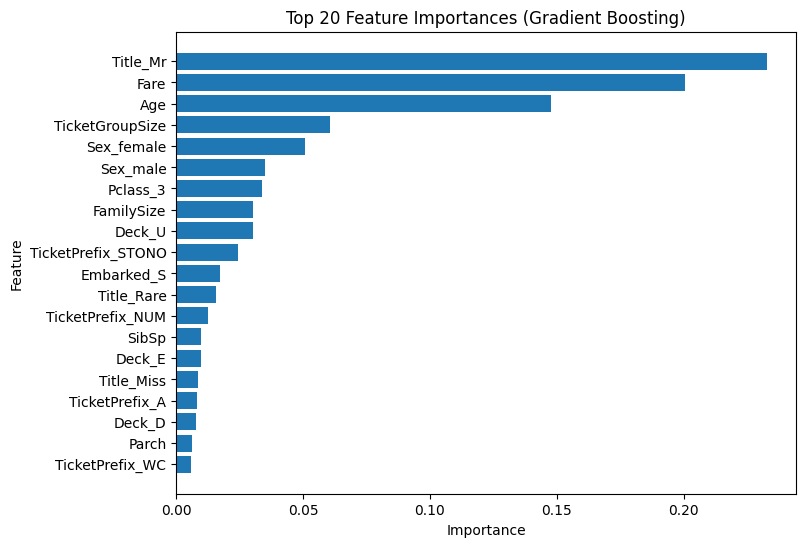

In [9]:
pre_step = best_gb.named_steps["pre"]
gb_clf = best_gb.named_steps["clf"]

try:
    feature_names = pre_step.get_feature_names_out()
except Exception:
    feature_names = [f"f{i}" for i in range(len(gb_clf.feature_importances_))]

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_clf.feature_importances_
}).sort_values("importance", ascending=False)
fi.head(20)

topk = fi.head(20)
plt.figure(figsize=(8, 6))
plt.barh(topk["feature"], topk["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Persist Best Pipeline (Optional)

Save the tuned GB pipeline with preprocessing for later reuse (validation, inference, or submission generation).


In [10]:
import joblib
OUT_DIR = ROOT / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_gb, OUT_DIR / "best_gb_pipeline.joblib")
print("Saved ->", OUT_DIR / "best_gb_pipeline.joblib")


Saved -> C:\Users\hasti_aksoy\OneDrive\Desktop\Titanic\models\best_gb_pipeline.joblib


## Train on Full Data + Submission (0.5 or Best Threshold)

Refit GB on all training data with class weights. Predict on processed test data and save `submission.csv`. If `best_thr` exists, we’ll use it; otherwise we default to 0.5.


In [11]:
# Recompute class weights on full training target
classes_full = np.unique(y)
w_full = compute_class_weight(class_weight="balanced", classes=classes_full, y=y)
wmap_full = dict(zip(classes_full, w_full))
sw_full = y.map(wmap_full).values
print("Class weights (full):", wmap_full)

# Use tuned params from best_gb
tuned_params = best_gb.named_steps["clf"].get_params()
tuned_params.setdefault("loss", "log_loss")
tuned_params.setdefault("random_state", 42)

gb_full = GradientBoostingClassifier(**tuned_params)
pipe_full = Pipeline([
    ("pre", build_preprocess_pipeline(X.assign(Survived=y))),
    ("clf", gb_full)
])
pipe_full.fit(X, y, clf__sample_weight=sw_full)

# Load processed test and prepare features
DATA_DIR = ROOT / "data" / "processed"
test_clean = pd.read_csv(DATA_DIR / "test_clean.csv")
X_test = test_clean.drop(columns=["PassengerId"])

# Decide threshold: use best_thr if available, else 0.5
use_thr = 0.5
if 'best_thr' in globals():
    try:
        if 0.0 < float(best_thr) < 1.0:
            use_thr = float(best_thr)
            print(f"[info] Using validation threshold: {use_thr:.3f}")
    except Exception:
        pass

if abs(use_thr - 0.5) < 1e-12:
    y_test_pred = pipe_full.predict(X_test)
else:
    y_test_proba = pipe_full.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= use_thr).astype(int)

sub = pd.DataFrame({"PassengerId": test_clean["PassengerId"], "Survived": y_test_pred})
out_path = ROOT / "submission.csv"
sub.to_csv(out_path, index=False)
print("Submission saved to:", out_path)
sub.head()


Class weights (full): {np.int64(0): np.float64(0.8114754098360656), np.int64(1): np.float64(1.3026315789473684)}
[info] Using validation threshold: 0.500
Submission saved to: C:\Users\hasti_aksoy\OneDrive\Desktop\Titanic\submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Submission with Custom Threshold (Explicit)

Always apply the selected validation threshold `best_thr` (fallback to 0.5 if missing) and save `submission_threshold.csv`.


In [12]:
# Fallback if best_thr not found
if 'best_thr' not in globals():
    best_thr = 0.5

gb_full_2 = GradientBoostingClassifier(**tuned_params)
pipe_full_2 = Pipeline([
    ("pre", build_preprocess_pipeline(X.assign(Survived=y))),
    ("clf", gb_full_2)
])
pipe_full_2.fit(X, y, clf__sample_weight=sw_full)

y_test_proba = pipe_full_2.predict_proba(X_test)[:, 1]
y_test_pred_thr = (y_test_proba >= float(best_thr)).astype(int)

sub_thr = pd.DataFrame({"PassengerId": test_clean["PassengerId"], "Survived": y_test_pred_thr})
out_path_thr = ROOT / "submission_threshold.csv"
sub_thr.to_csv(out_path_thr, index=False)
print("Submission (custom threshold) saved to:", out_path_thr)
sub_thr.head()


Submission (custom threshold) saved to: C:\Users\hasti_aksoy\OneDrive\Desktop\Titanic\submission_threshold.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
